### A nasty integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)


In [17]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

For Monte Carlo integration we need to write our integral as:
$$ I = \int f(x) p(x) dx$$
So, in our case:
$$f(x) = \sigma\sqrt{2\pi} x^3$$
$$p(x) = \frac{2}{\sigma\sqrt{2\pi}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$$

In [27]:
mu = 0
sigma = 2
true_res = 4*sigma**4
N = 1000
gauss = scipy.stats.norm(mu, sigma)

samples = np.abs(gauss.rvs(N)) # Only positive values since i have to integrate from 0 to infinity

I = sigma*np.sqrt(np.pi*2)*np.mean(samples**3)

print("Monte Carlo result = ", I)
print("Result error = ", np.abs(I - true_res)/true_res)
print("True result = ", true_res)

Monte Carlo result =  68.81967985559056
Result error =  0.07530749774360257
True result =  64


Let's see if the result converges with the number of samples and how the error goes:

In [28]:
N = np.logspace(1, 6, 100, dtype=int) # Number of sample draws from 10 to 10^6
result = []
error_res = []

for n in N:
    samples = np.abs(gauss.rvs(n))
    I = sigma*np.sqrt(np.pi*2)*np.mean(samples**3)
    result.append(I)
    error_res.append(np.abs((I-true_res)/true_res))

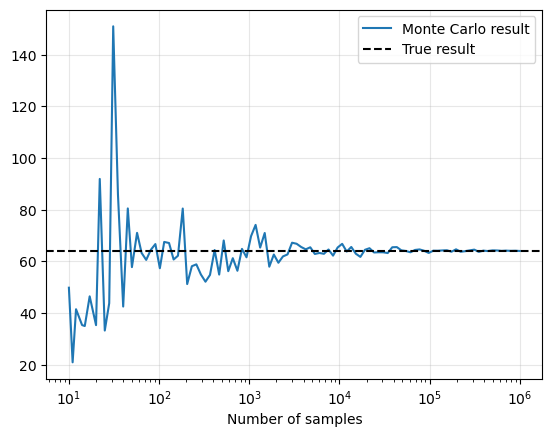

In [29]:
plt.plot(N, result, label='Monte Carlo result')
plt.axhline(true_res, color='k', linestyle='--', label='True result')
plt.xlabel('Number of samples')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend()

The result converges with the number of samples!

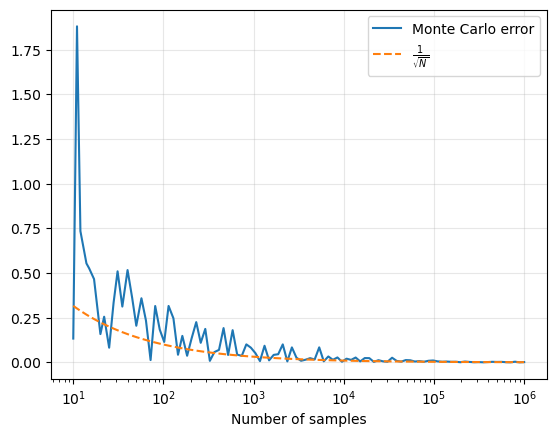

In [26]:
plt.plot(N, error_res, label='Monte Carlo error')
plt.plot(N, N**-0.5, linestyle='--', label=r'$\frac{1}{\sqrt{N}}$')
plt.xscale('log')
plt.xlabel('Number of samples')
plt.grid(alpha=0.3)
plt.legend()

The error goes down as expected!

Let's now see how the results are distributed for a given number of samples:

In [33]:
N_simulation = 10000
N_big = 10000
N_small = 100
res_big = []
res_small = []
error_big = []
error_small = []

for n in range(N_simulation):
    samples_big = np.abs(gauss.rvs(N_big))
    samples_small = np.abs(gauss.rvs(N_small))
    I_big = sigma*np.sqrt(np.pi*2)*np.mean(samples_big**3)
    I_small = sigma*np.sqrt(np.pi*2)*np.mean(samples_small**3)
    res_big.append(I_big)
    res_small.append(I_small)
    error_big.append(np.abs((I_big - true_res)/true_res))
    error_small.append(np.abs((I_small - true_res)/true_res))

mu_results = [np.mean(res_small), np.mean(res_big)]
sigma_results = [np.std(res_small), np.std(res_big)]

pdf_big = scipy.stats.norm(mu_results[1], sigma_results[1])
pdf_small = scipy.stats.norm(mu_results[0], sigma_results[0])

print('High N: \u03bc = ',mu_results[1], '\u03c3 = ', sigma_results[1])
print('Low N: \u03bc = ',mu_results[0], '\u03c3 = ', sigma_results[0])

High N: μ =  64.03060711552988 σ =  1.4292491340549576
Low N: μ =  63.760793340894175 σ =  14.078889016835596


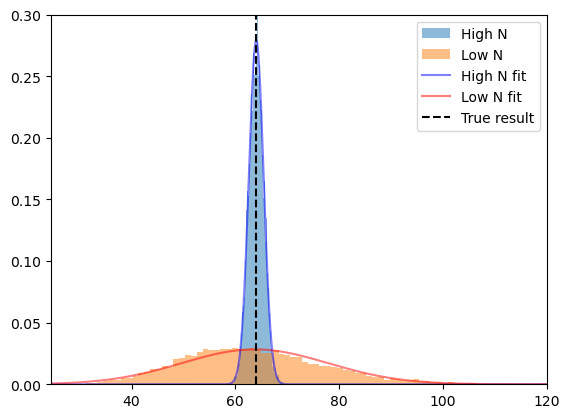

In [34]:
x = np.linspace(np.min(res_small), np.max(res_small), 1000)
plt.hist(res_big, bins=100, alpha=0.5, density=True, label='High N')
plt.hist(res_small, bins=100, alpha=0.5, density=True, label='Low N')
plt.plot(x, pdf_big.pdf(x), 'b', alpha = 0.5, label='High N fit')
plt.plot(x, pdf_small.pdf(x), 'r', alpha = 0.5, label='Low N fit')
plt.vlines(true_res, 0., 0.30, 'k', linestyles='--', label='True result')
plt.ylim(0, 0.30)
plt.xlim (np.min(res_small), 120)
plt.legend()

The distribution of our results looks like a gaussian centered in the true result of the integral!
The higher the number of samples we take, the lower $\sigma$ will be, so our results will be distributed closer to the true result!